In [1]:
import pandas as pd
df_meta=pd.read_csv('cancer_meta.csv',index_col=0)
df_meta=df_meta.T
df_meta = df_meta.loc[:, df_meta.loc['age'].notna()]
#only keep where 'age' row is not none

/tmp/ipykernel_792191/3794608709.py:2: DtypeWarning: Columns (3,4,11,12,13,23,28,35,36,37,41,49,50,61,63,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df_meta=pd.read_csv('cancer_meta.csv',index_col=0)


In [ ]:
#READ BETA VALUES
import pandas as pd
betas = pd.read_pickle("/mnt/idms/home/TMP/speter_meth.pkl")
betas=betas.T

In [ ]:
import pandas as pd

file_path = "cancer_methylation_v1.txt"

# Read the first 4 lines without loading the full file
first_4_lines = []
with open(file_path, "r") as file:
    for i in range(4):
        first_4_lines.append(file.readline().strip())  # Read line and remove newline

# Convert the first 4 lines into a DataFrame with tab-separated values
meta_for_col = pd.DataFrame([line.split("\t") for line in first_4_lines])

# Set the first column as the index
meta_for_col.set_index(meta_for_col.columns[0], inplace=True)
meta_for_col.index.name = None 
# Set the first row (now index) as column names and remove it from the data
meta_for_col.columns = meta_for_col.iloc[0]  # Assign first row as column names
meta_for_col = meta_for_col[1:]  # Remove the first row from data
betas.columns=meta_for_col.columns

In [ ]:
#get cg74 related cgs in a list
file_path = "../../inflammation_HANNUM_with_proper_selection/cd_74_associated_cpgs.txt"
with open(file_path, "r") as file:
    cd_74_associated_cpgs_list = [line.strip() for line in file]  # Removes any trailing newlines
cd_74_associated_cpgs_set=set(cd_74_associated_cpgs_list)
#keep only rows which are in the infl_cg_set
filtered_betas = betas[betas.index.isin(cd_74_associated_cpgs_set)] #all the cg sites are present
#have matching order indices
df_meta = df_meta.loc[:, ~df_meta.columns.duplicated(keep='first')]

In [ ]:
#only keep columns which are in the filtered beta df
filtered_betas = filtered_betas[list(df_meta.columns)]
#still duplicates left (but only 'good' ones) so now we have to remove the duplicates
filtered_betas = filtered_betas.loc[:, ~filtered_betas.columns.duplicated(keep='first')]
#finally they have same cols in same order, and only samples where we have 'age' availabe
#list(filtered_betas.columns)==list(df_meta.columns) #check if they are the same

In [12]:
import joblib

with open("../../hugging_face_diseases/inflamm_hugging_xgbost_all_cg_order.txt", "r") as f:
    hugging_elnet_cg_order = [line.strip() for line in f.readlines()]

model_filename='../../hugging_face_diseases/hugging_inflamm_elastic_5.9MAE.pkl'
loaded_pipeline = joblib.load(model_filename)

In [ ]:
#reorder betas to the same order as our model was trained on (every cg in hannum is in this df too)
filtered_betas_reordered = filtered_betas.reindex(hugging_elnet_cg_order)
#fill missing values
filtered_betas_reordered.fillna(filtered_betas_reordered.mean(), inplace=True)

In [40]:
df_meta

sample_id,TARGET-20-PADYIR-04A-01D,TARGET-20-PADZCG-04A-02D,TARGET-20-PADZCG-09A-01D,TARGET-20-PAECCE-04A-02D,TARGET-20-PAECCE-09A-01D,TARGET-20-PAEDKB-04A-01D,TARGET-20-PAEDKB-09A-01D,TARGET-20-PAEDKB-10A-01D,TARGET-20-PAEERJ-04A-01D,TARGET-20-PAEFGR-04A-02D,...,TCGA-WC-A883-01A-12D-A39X-05,TCGA-WC-A885-01A-11D-A39X-05,TCGA-WC-A888-01A-11D-A39X-05,TCGA-WC-A88A-01A-11D-A39X-05,TCGA-WC-AA9A-01A-11D-A39X-05,TCGA-WC-AA9E-01A-11D-A39X-05,TCGA-YZ-A980-01A-11D-A39X-05,TCGA-YZ-A983-01A-11D-A39X-05,TCGA-YZ-A984-01A-11D-A39X-05,TCGA-YZ-A985-01A-11D-A39X-05
age,3.17534,14.589,14.589,2.46575,2.46575,2.23288,2.23288,2.23288,13.9233,1.50411,...,76.5836,60.2137,77.0329,75.9507,70.2493,60.2082,75.9342,51.4219,50.2521,41.5452
age_at_menarche,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atopy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blood_lead_level,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
weight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,58.5,90.0,54.9,106.8,61.1,90.0,81.103,59.784,75.932,115.395
years_of_smoking,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tissue_or_organ_of_origin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,choroid,choroid,choroid,choroid,choroid,choroid,choroid,choroid,choroid,choroid
sample_type,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,...,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue,disease tissue


In [ ]:
#delete samples from a 120 years old woman, 30 samples from 1 person will distort the results
very_old_woman_30_samples=df_meta.T[df_meta.loc['age'] > 100].T # GSM1572442 or Series GSE64491
#delete these from the dataset
df_meta = df_meta.drop(columns=list(very_old_woman_30_samples.columns))
filtered_betas_reordered = filtered_betas_reordered.drop(columns=list(very_old_woman_30_samples.columns))

In [64]:
filtered_betas_reordered = filtered_betas_reordered[list(df_meta.columns)]

In [66]:
#PREDICT:
import numpy as np

predictions_list = []

# Loop over each column in the DataFrame (assuming you want predictions for each column)
for col in filtered_betas_reordered.columns:
    X_test = np.array(filtered_betas_reordered[col]).reshape(1, -1)  # Reshape the column into the right shape
    prediction = loaded_pipeline.predict(X_test)[0]  # Get prediction for the current column
    predictions_list.append(prediction)  # Append the prediction to the list

In [67]:
predictions_list

[10.31757595707466,
 38.629085321078044,
 22.578195450495464,
 48.091178536282996,
 39.29207262087161,
 10.200938415510024,
 6.173673811443017,
 4.681251446589201,
 14.202993711799774,
 14.431363805571607,
 43.103518433290475,
 69.92342300037566,
 8.61006839149966,
 29.293016483702054,
 75.13936918458074,
 50.179839478108505,
 22.40759262071785,
 30.88818790279192,
 19.91262790962829,
 38.92036068119931,
 21.18898617019057,
 69.88706570091553,
 39.68355921747137,
 55.35865511984249,
 61.673552865728155,
 24.35117341017265,
 30.344119615898485,
 38.68790527883431,
 42.133856109119876,
 12.748185225590873,
 56.924725426898036,
 62.04523914655991,
 27.707237636664104,
 17.383474029009108,
 44.20007536021219,
 64.60660039152407,
 21.40902367153388,
 70.47960480265945,
 31.233352217668187,
 72.74451677749522,
 48.850902306062494,
 21.955624695321088,
 41.14948970028017,
 42.57721597790043,
 20.70264109572885,
 14.118004283447078,
 0.8628079354906362,
 6.384528910710536,
 34.880100922903694,

In [69]:
#WHICH SAMPLE TYPE APPEARS HOW MANY TIMES
sample_type_counts = df_meta.loc['sample_type'].value_counts()
# Print the result
print(sample_type_counts)

sample_type
disease tissue     5675
control            1155
adjacent normal     864
Name: count, dtype: int64


In [70]:
import numpy as np
import scipy.stats as stats
predictions=predictions_list
# Extract X and Y values
x_values = df_meta.loc['age']
y_values = predictions

# Calculate Mean Absolute Error (MAE)
mae = np.mean(np.abs(y_values - x_values))

# Calculate Pearson correlation coefficient (r)
pearson_r, _ = stats.pearsonr(x_values, y_values)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Pearson Correlation Coefficient (r): {pearson_r:.4f}")

Mean Absolute Error (MAE): 23.1581
Pearson Correlation Coefficient (r): 0.4905


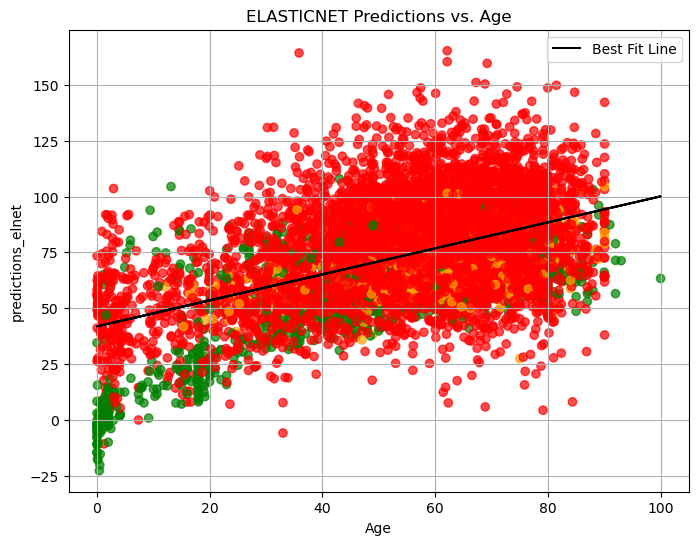

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Extract X and Y values for the scatter plot and ensure they are numeric
x_values = pd.to_numeric(df_meta.loc['age'], errors='coerce')  # Convert to numeric, invalid parsing will be NaN
y_values = pd.to_numeric(predictions, errors='coerce')  # Convert to numeric, invalid parsing will be NaN
class_values = df_meta.loc['sample_type']  # Extract class labels

# Define colors: Green for 'HC', Red for others
colors = ['red' if cls == 'disease tissue' 
          else 'orange' if cls == 'adjacent normal' 
          else 'green' for cls in class_values]

# Calculate the line of best fit using polyfit
slope, intercept = np.polyfit(x_values, y_values, 1)  # 1 indicates a linear fit

# Store the best fitting line function
def best_fit_line(x):
    return slope * x + intercept

# Generate the y-values for the best fitting line
y_best_fit = best_fit_line(x_values)

# Plot the scatter plot with colored points
plt.figure(figsize=(8, 6))
plt.scatter(x_values, y_values, color=colors, alpha=0.7)

# Plot the best fit line
plt.plot(x_values, y_best_fit, color='black', label='Best Fit Line')

# Labels and title
plt.xlabel('Age')
plt.ylabel('predictions_elnet')
plt.title('ELASTICNET Predictions vs. Age')

# Show the legend
plt.legend()

# Show the plot with grid
plt.grid(True)
plt.show()


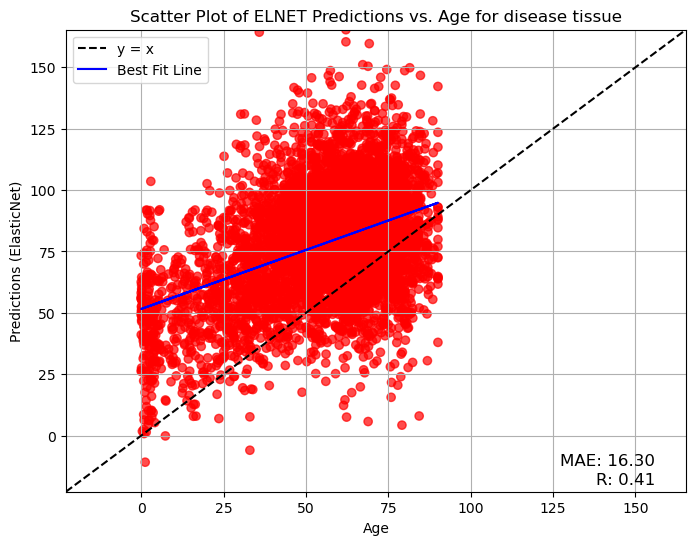

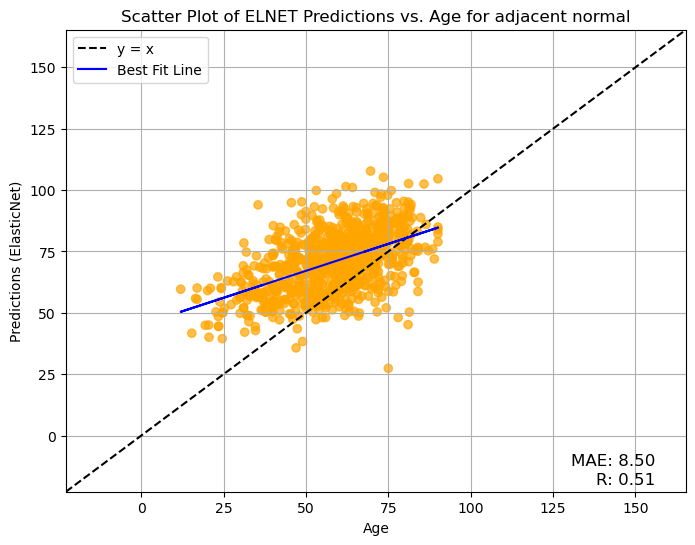

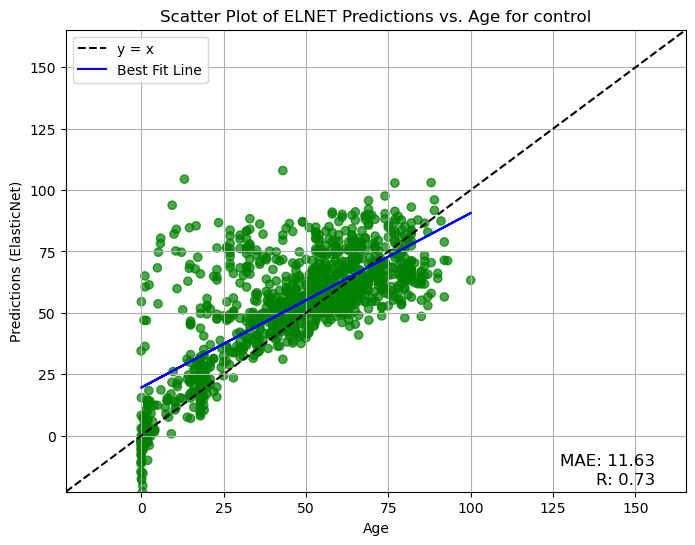

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# Assuming df_meta is your DataFrame containing the data
# Extract X, Y, and class values and ensure proper alignment
x_values = df_meta.loc['age']
y_values = pd.Series(predictions, index=x_values.index)  # Ensure predictions are aligned with x_values
class_values = df_meta.loc['sample_type']

# Define colors: Green for 'control', Orange for 'adjacent normal', Red for 'disease tissue'
colors = ['red' if cls == 'disease tissue' 
          else 'orange' if cls == 'adjacent normal' 
          else 'green' for cls in class_values]

# Create separate scatter plots based on class
unique_classes = ['disease tissue', 'adjacent normal', 'control']

# Get the global limits for x and y for consistent scaling across all plots
x_min, x_max = min(x_values), max(x_values)
y_min, y_max = min(y_values), max(y_values)

# Set the limits for the axes to be the same on all plots
axis_limits = [min(x_min, y_min), max(x_max, y_max)]

# Iterate through each class and plot separately
for class_label in unique_classes:
    plt.figure(figsize=(8, 6))
    
    # Filter data based on class label (ensure proper alignment with the DataFrame)
    class_filter = class_values == class_label
    x_class = x_values[class_filter]
    y_class = y_values[class_filter]
    
    # Remove any NaN values from x_class and y_class
    valid_data_filter = ~x_class.isna() & ~y_class.isna()
    x_class = x_class[valid_data_filter]
    y_class = y_class[valid_data_filter]

    # Convert to numeric to avoid dtype=object issues
    x_class = pd.to_numeric(x_class, errors='coerce')
    y_class = pd.to_numeric(y_class, errors='coerce')

    # Filter colors for the current class using correct positional access
    colors_class = [colors[i] for i in range(len(colors)) if class_values.iloc[i] == class_label]

    # Plot the scatter plot for the current class
    plt.scatter(x_class, y_class, color=colors_class, alpha=0.7)

    # Plot the x=y line (45-degree line)
    plt.plot(axis_limits, axis_limits, color='black', linestyle='--', label='y = x')

    # Fit a line to the data (best fitting line)
    fit_line = np.polyfit(x_class, y_class, 1)
    fit_line_fn = np.poly1d(fit_line)
    plt.plot(x_class, fit_line_fn(x_class), color='blue', label='Best Fit Line')

    # Calculate MAE and Pearson correlation coefficient (R)
    mae = mean_absolute_error(y_class, fit_line_fn(x_class))
    r, _ = pearsonr(x_class, y_class)  # Pearson correlation coefficient

    # Annotate MAE and R on the plot (bottom-right corner)
    plt.annotate(f'MAE: {mae:.2f}', xy=(0.95, 0.05), xycoords='axes fraction', fontsize=12, verticalalignment='bottom', horizontalalignment='right')
    plt.annotate(f'R: {r:.2f}', xy=(0.95, 0.01), xycoords='axes fraction', fontsize=12, verticalalignment='bottom', horizontalalignment='right')

    # Set axis limits to be the same for all plots
    plt.xlim(axis_limits)
    plt.ylim(axis_limits)

    # Set labels and title
    plt.xlabel('Age')
    plt.ylabel('Predictions (ElasticNet)')
    plt.title(f'Scatter Plot of ELNET Predictions vs. Age for {class_label}')
    
    # Add a grid and legend
    plt.grid(True)
    plt.legend()

    # Show the plot
    plt.show()


In [73]:
# Extract X, Y, and class values
x_values = df_meta.loc['age']
y_values = pd.Series(predictions, index=x_values.index)  # Ensure alignment
class_values = df_meta.loc['sample_type']

# Create masks for each class
mask_control = class_values == 'control'
mask_adj_normal = class_values == 'adjacent normal'
mask_disease = class_values == 'disease tissue'

# Clean and convert all data to numeric, suppressing invalids
x_values = pd.to_numeric(x_values, errors='coerce')
y_values = pd.to_numeric(y_values, errors='coerce')

# Apply masks and drop NaNs
control_age = x_values[mask_control & x_values.notna() & y_values.notna()].tolist()
control_predictions = y_values[mask_control & x_values.notna() & y_values.notna()].tolist()

adj_normal_age = x_values[mask_adj_normal & x_values.notna() & y_values.notna()].tolist()
adj_normal_predictions = y_values[mask_adj_normal & x_values.notna() & y_values.notna()].tolist()

disease_tissue_age = x_values[mask_disease & x_values.notna() & y_values.notna()].tolist()
disease_tissue_predictions = y_values[mask_disease & x_values.notna() & y_values.notna()].tolist()

In [75]:
# Previously calculated slope and intercept from polyfit
slope, intercept = np.polyfit(x_values, y_values, 1)

# Define the best fit line function
def best_fit_line(x):
    return slope * x + intercept

# Calculate the vertical distance from each point to the best fit line
def calculate_distance(real_age, predicted_age):
    diff = predicted_age - best_fit_line(real_age)  # Predicted y value from the best fit line
    return diff  # Vertical distance

# Calculate the age acceleration for each group

# For control group
control_acceleration = [calculate_distance(x, y) for x, y in zip(control_age, control_predictions)]
# For adjacent normal group
adj_normal_acceleration = [calculate_distance(x, y) for x, y in zip(adj_normal_age, adj_normal_predictions)]
# For disease tissue group
disease_tissue_acceleration = [calculate_distance(x, y) for x, y in zip(disease_tissue_age, disease_tissue_predictions)]

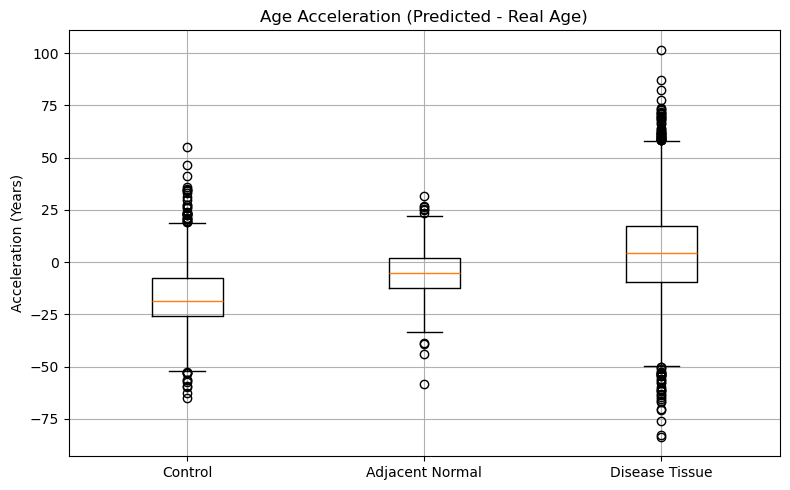

T-Test Results on Age Acceleration:
--------------------------------------------------
Control vs Adjacent Normal:
  T-statistic: -18.9207
  P-value: 0.0000
  ✅ Statistically significant (p < 0.05)

Control vs Disease Tissue:
  T-statistic: -37.7103
  P-value: 0.0000
  ✅ Statistically significant (p < 0.05)

Adjacent Normal vs Disease Tissue:
  T-statistic: -19.7027
  P-value: 0.0000
  ✅ Statistically significant (p < 0.05)



In [ ]:
# Prepare data and labels for boxplot
acceleration_data = [
    control_acceleration,
    adj_normal_acceleration,
    disease_tissue_acceleration
]
labels = ['Control', 'Adjacent Normal', 'Disease Tissue']

# Plot boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(acceleration_data, labels=labels)
plt.title('Age Acceleration (Age predictions difference from best fitting line)')
plt.ylabel('Acceleration (Years)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Run t-tests
comparisons = [
    ('Control', control_acceleration, 'Adjacent Normal', adj_normal_acceleration),
    ('Control', control_acceleration, 'Disease Tissue', disease_tissue_acceleration),
    ('Adjacent Normal', adj_normal_acceleration, 'Disease Tissue', disease_tissue_acceleration),
]

print("T-Test Results on Age Acceleration:")
print("-" * 50)
for label1, group1, label2, group2 in comparisons:
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    print(f"{label1} vs {label2}:")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  ✅ Statistically significant (p < 0.05)")
    else:
        print("  ❌ Not statistically significant (p ≥ 0.05)")
    print()

In [77]:
meta_important=df_meta.loc[['age','disease','tissue','sample_type']]
meta_important.loc['predictions']= pd.Series(predictions, index=x_values.index)
meta_important = meta_important.dropna(axis=1)#drop where nan appears
meta_important=meta_important.T

In [78]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder

# Define the dependent (Y) and independent variables (X)
X = meta_important[['age', 'sample_type']]
y = meta_important['predictions']
X = pd.get_dummies(X, columns=['sample_type'], drop_first=True)

# Convert everything to float
X = X.astype(float)
y = pd.to_numeric(y, errors='coerce')

X = sm.add_constant(X)  # Add constant for the intercept

# Fit the linear regression model
model = sm.OLS(y, X)  # Ordinary Least Squares regression (Linear Regression)
result = model.fit()

# Print the summary of the model to get the coefficients and p-values
print(result.summary())

# Optional: Calculate confidence intervals for coefficients
conf = result.conf_int()
print("\nConfidence Intervals for Coefficients:")
print(conf)


                            OLS Regression Results                            
Dep. Variable:            predictions   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     614.8
Date:                Tue, 08 Apr 2025   Prob (F-statistic):               0.00
Time:                        18:01:35   Log-Likelihood:                -29024.
No. Observations:                6585   AIC:                         5.806e+04
Df Residuals:                    6581   BIC:                         5.808e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               